In [ ]:
from astropy.visualization import ImageNormalize, LogStretch
import torch
import os, json, re
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
from astropy import units
from astropy.io import fits
from astropy.wcs import WCS
from torch.func import jacrev, jvp, vjp
from tqdm import tqdm

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

import sys
sys.path.append("../scripts/")
from kernel_slic import KernelSLIC, effective_kernel
from forward_model import make_forward_model

In [ ]:
@torch.no_grad()
def sample(self, batch_size, steps, *args):
    """
    An Euler-Maruyama integration of the model SDE

    steps: Number of Euler-Maruyam steps to perform
    """
    sampling_from = "noise distribution" 
    z = self.sde.prior(self.idim).sample([batch_size]).to(self.device)
    x = self.forward_model(z)
    dt = -(self.sde.T - self.sde.epsilon) / steps
    t = torch.ones(batch_size).to(self.device) * self.sde.T
    xs = []
    for _ in (pbar := tqdm(range(steps))):
        pbar.set_description(f"Sampling from the {sampling_from} | t = {t[0].item():.1f} | sigma = {self.sde.sigma(t)[0].item():.1e}"
                             f"| scale ~ {x.max().item():.1e}")
        t += dt
        if t[0] < self.sde.epsilon: # Accounts for numerical error in the way we discretize t.
            break
        g = self.sde.diffusion(t, x)
        f = self.sde.drift(t, x) - g**2 * self.score(t, x, *args) * model.low_pass**(1/2)
        dw = self.forward_model(torch.randn_like(z)) * (-dt)**(1/2)
        x_mean = x + f * dt
        x = x_mean + g * dw 
        if torch.any(torch.isnan(x)):
            print("Diffusion is not stable, NaN were produced. Stopped sampling.")
            break
        xs.append(x.cpu().numpy())
    return xs, x_mean


In [ ]:
# F814W targets
i = 1
coord1 = SkyCoord("9:57:56.5294", "2:27:37.963", unit=(units.hourangle, units.deg))
coord2 = SkyCoord("9:57:46.8867", "2:28:22.735", unit=(units.hourangle, units.deg))
coord3 = SkyCoord("9:57:49.1102", "2:28:19.430", unit=(units.hourangle, units.deg))
if i == 1:
    data = fits.open("../data/connors_target1.fits")
    coord = coord1
if i == 2:
    data = fits.open("../data/connors_target2.fits")
    coord = coord2
if i == 3:
    data = fits.open("../data/connors_target3.fits")
    coord = coord3

data.info()

In [ ]:
model_pixels = 64
model_pixel_size = 0.05#/4
super_sampling_factor = 4 # for the PSF

n_obs = 1

# Make the forward model with one FLAT field target
observations = torch.stack([torch.tensor(data[2+i].data.astype(np.float32)).to(DEVICE) for i in range(n_obs)], dim=0)[None] # [1, 4, ...], use channel for broadcasting
wcs_list = [WCS(data[2+i].header, data) for i in range(n_obs)]
psf_file = "/home/aadam/scratch/DeblendingGalaxies/data/F814w_WFC3UV_psf.fits"
with fits.open(psf_file) as psf_data:
    psf = psf_data["PRIMARY"].data[None].astype(np.float32) # add the channel dimension, a single channel for now.
forward_model = make_forward_model(
    psf, 
    wcs_list, 
    super_sampling_factor=super_sampling_factor,
    model_pixels=model_pixels,
    model_pixel_size=model_pixel_size * units.arcsec,
    fiducial_center=coord,
    # fiducial_orientation=80
)

In [ ]:
# Contruct the effective kernel of the forward model for KernelSLIC
in_dim = [1, model_pixels, model_pixels]
out_dim = [1, 64, 64]
kernel = effective_kernel(forward_model, in_dim, out_dim, 0, model_pixels//2, model_pixels//2).view(1, 64, 64)

In [ ]:
checkpoint_dir = "/home/aadam/scratch/DeblendingGalaxies/models/ncsnpp_vp_hst_noise_flat_field_psf_f814w_ssf1_230816214815"


model = KernelSLIC(in_dim, out_dim, forward_model, checkpoints_directory=checkpoint_dir)
print(f"Model has {sum([np.prod(p.shape) for p in model.parameters()]) / 1e6:.2f} million parameters")

In [ ]:
z = model.sde.prior(model.idim).sample([1]).to(DEVICE)
z = model.forward_model(z)
plt.imshow(z.cpu().detach().squeeze())

In [ ]:
t = torch.ones([1]).to(DEVICE)
plt.imshow(model.score(t, z).cpu().detach().squeeze() * model.low_pass**(1/2), cmap="bwr", norm=plt.cm.colors.CenteredNorm())
plt.colorbar()

In [ ]:
plt.imshow(model._transition_kernel_score(z).cpu().detach().squeeze(), cmap="bwr", norm=plt.cm.colors.CenteredNorm())
plt.colorbar()

In [ ]:
N = 1000
# samples = model.sample(16, N)
chain, samples = sample(model, 16, N)

In [ ]:
fig, axs = plt.subplots(2, 5, figsize=(20, 8))
for i in range(2):
    for j in range(5):
        k = i * 5 + j
        axs[i, j].imshow(chain[k*100][0].squeeze(), cmap="gray")
        axs[i, j].axis("off")

In [ ]:
fig, axs = plt.subplots(4, 4, figsize=(16, 16))
for i in range(4):
    for j in range(4):
        axs[i, j].imshow(samples[i*4+j].squeeze().cpu(), cmap="gray")
        axs[i, j].axis("off")

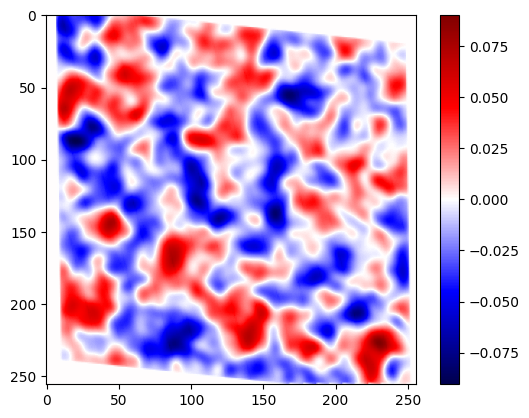

In [10]:
with torch.no_grad():
    x = torch.randn(1, 1, model_pixels, model_pixels).to(DEVICE)
    x1 = torch.randn(1, 1, model_pixels, model_pixels).to(DEVICE)
    y = forward_model(x1)
    t = torch.ones(1).to(DEVICE) * 0.5

    plt.imshow(model.slic_score(t, x, y).cpu().squeeze(), cmap="seismic")
    plt.colorbar()

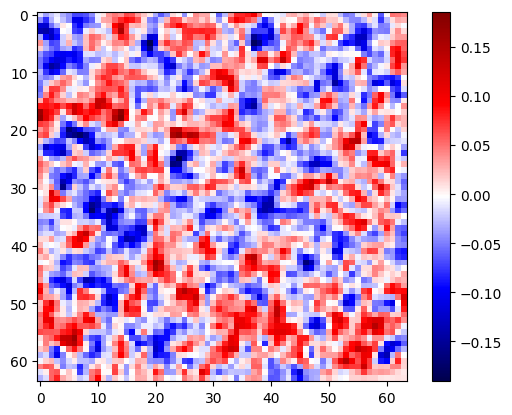

In [11]:
plt.imshow(y.cpu().squeeze(), cmap="seismic")
plt.colorbar()

# IR filters

In [30]:
i = 0
coord0 = SkyCoord("7:23:24.5462", "-73:27:20.172", unit=(units.hourangle, units.deg))
coord1 = SkyCoord("7:23:22.0805", "-73:27:24.575", unit=(units.hourangle, units.deg))
coord2 = SkyCoord("7:23:20.7483", "-73:26:07.203", unit=(units.hourangle, units.deg))
coord3 = SkyCoord("7:23:01.6118", "-73:26:45.888", unit=(units.hourangle, units.deg))
coord = [coord0, coord1, coord2, coord3][i]

FILTER = "F105W" # "F125W", "F160W
paths = glob(f"../data/smacs*target{i}*{FILTER}*.fits")
data = []
for p in paths:
    data.append(fits.open(p))

In [31]:
model_pixels = 32
model_pixel_size = 0.13 #/ 8
super_sampling_factor = 4 # for the PSF

n_obs = 1

# Make the forward model with one FLAT field target
observation = torch.tensor(data[0][1].data.astype(np.float32)).to(DEVICE)
wcs_list = [WCS(data[0][1].header, data[0])]
psf_file = "/home/aadam/scratch/DeblendingGalaxies/data/F105w_WFC3IR_psf.fits"
with fits.open(psf_file) as psf_data:
    psf = psf_data["PRIMARY"].data[None].astype(np.float32) # add the channel dimension, a single channel for now.
forward_model = make_forward_model(
    psf, 
    wcs_list, 
    super_sampling_factor=super_sampling_factor,
    model_pixels=model_pixels,
    model_pixel_size=model_pixel_size * units.arcsec,
    fiducial_center=coord,
    # fiducial_orientation=80
)

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN'  'DEC--TAN'  
CRVAL : 110.8522758333333  -73.45560333333334  
CRPIX : 15.5  15.5  
PC1_1 PC1_2  : -2.6046291982728e-05  2.50120574849307e-05  
PC2_1 PC2_2  : 2.50120574849307e-05  2.60462919827282e-05  
CDELT : 1.0  1.0  
NAXIS : 32  32


In [41]:
# Contruct the effective kernel of the forward model for KernelSLIC
in_dim = [1, model_pixels, model_pixels]
out_dim = [1, 32, 32]
kernel = effective_kernel(forward_model, in_dim, out_dim, 0, model_pixels//2, model_pixels//2).view(1, 32, 32)

In [16]:
checkpoint_dir = "/home/aadam/scratch/DeblendingGalaxies/models/ncsnpp_vp_hst_noise_flat_field_psf_f105w_ssf1_230815090237"


model = KernelSLIC(kernel, in_dim, forward_model, checkpoints_directory=checkpoint_dir)
print(f"Model has {sum([np.prod(p.shape) for p in model.parameters()]) / 1e6:.2f} million parameters")

Model has 29.96 million parameters


In [17]:
N = 1000
chain, samples = sample(model, 16, N)

Sampling from the noise distribution | t = 0.0 | sigma = 4.5e-03| scale ~ 1.2e+01: 100%|██████████| 1000/1000 [00:29<00:00, 33.92it/s]


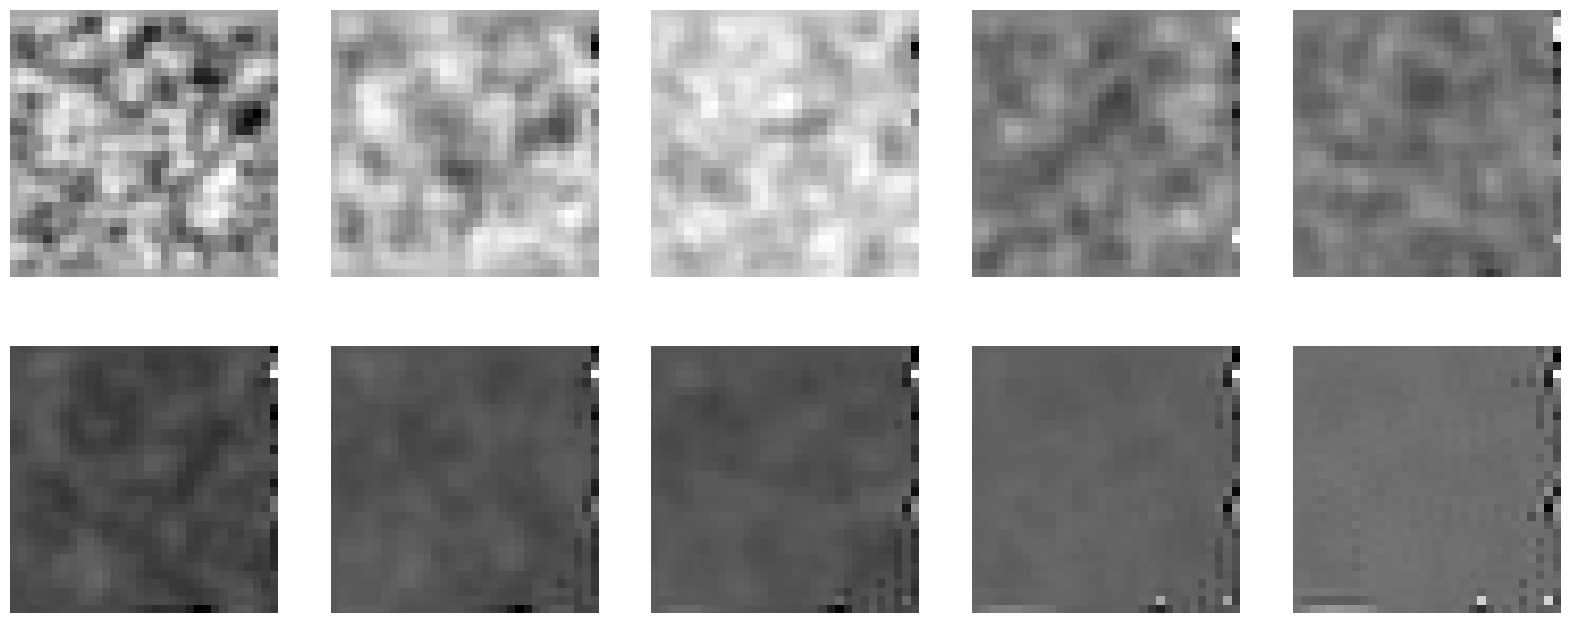

In [18]:
fig, axs = plt.subplots(2, 5, figsize=(20, 8))

for i in range(2):
    for j in range(5):
        k = i * 5 + j
        axs[i, j].imshow(chain[k*100][0].squeeze(), cmap="gray")
        axs[i, j].axis("off")

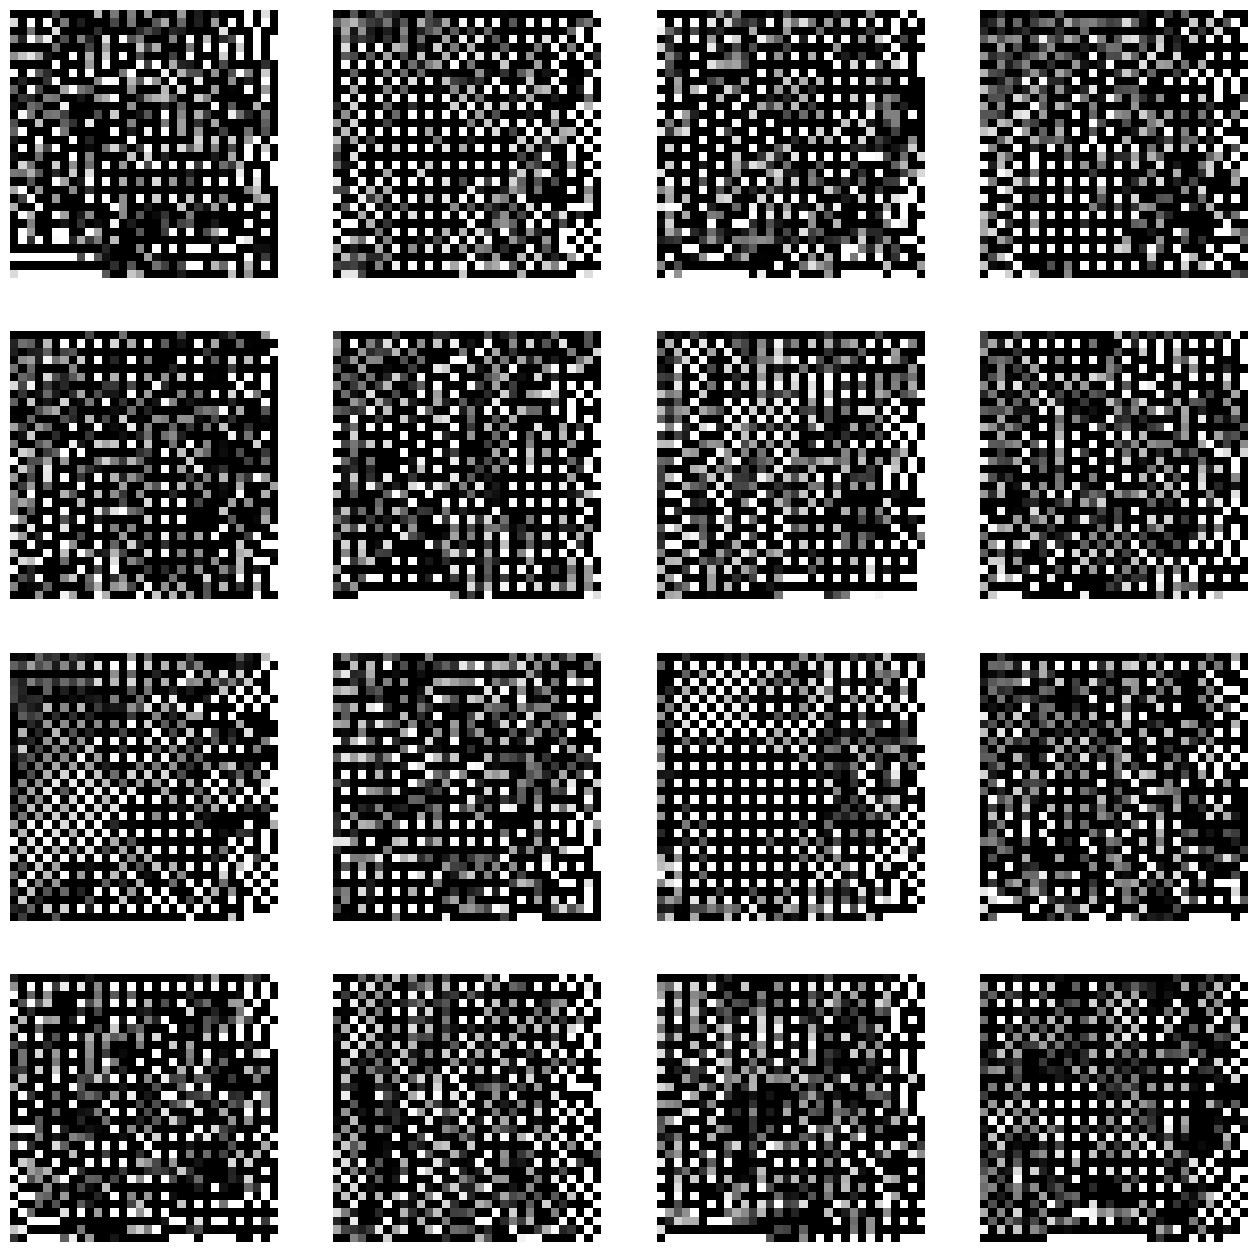

In [19]:
fig, axs = plt.subplots(4, 4, figsize=(16, 16))
for i in range(4):
    for j in range(4):
        axs[i, j].imshow(samples[i*4+j].squeeze().cpu(), cmap="gray", vmin=-0.04, vmax=0.08)
        axs[i, j].axis("off")

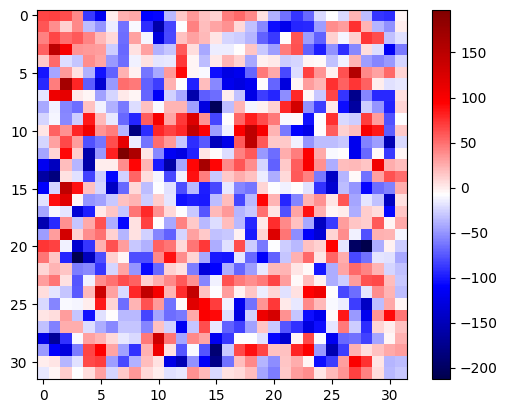

In [20]:
with torch.no_grad():
    x = torch.randn(1, 1, model_pixels, model_pixels).to(DEVICE)
    x1 = torch.randn(1, 1, model_pixels, model_pixels).to(DEVICE)
    y = forward_model(x1)
    t = torch.ones(1).to(DEVICE) * 0.01

    plt.imshow(model.score(t, x, y).cpu().squeeze(), cmap="seismic")
    plt.colorbar()

In [20]:
plt.imshow(y.cpu().squeeze(), cmap="seismic")
plt.colorbar()

KeyboardInterrupt: 